<a href="https://colab.research.google.com/github/LuxTenebriis/SMC_SED/blob/main/Lux_SMC_SED_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ★ SMC Stellar Energy Distribution Plots ★

☆ last updated: 10/05/2026
<br>
<br>
LAYOUT☆☆☆<br>
Setup ⟶ import all packagaes, set path directories and define photometry columns <br>
Functions ⟶  implement the standarised functions for data processing (aka "cleaning" the columns) and plotting the diagrams
<br><br>
YSG ⟶ calls the functions for analysis of YSG candidates <br>
<br>
☆ U-M GPT was used to assist with Python syntax, code organization, debugging, and editing.

---



## ★ SETUP

In [1]:
import pandas as pd
import numpy as np
import csv
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

In [3]:
#connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#set up paths
main_path= Path("/content/drive/MyDrive/★ Research/Unresolved Binaries")
data_path = main_path / "Data/SMC_Data/"
YSG_path = data_path / "smc_ysg.csv"
RSG_path = data_path / "smc_rsg.csv"
BSG_path = data_path / "smc_bsg.csv"
output_path= main_path / "Outputs/SED"

In [5]:
# define column names
magnitude_cols = [
    "umagSkyM",
    "vmagSkyM",
    "imagSkyM"
]

error_cols = [
    "e_umagSkyM",
    "e_vmagSkyM",
    "e_imagSkyM"
]

# Approximate SkyMapper filter central wavelengths in nanometers
wavelengths = np.array([
    349.0,  # SkyMapper u
    384.0,  # SkyMapper v
    779.0   # SkyMapper i
])

## ★ FUNCTIONS

In [8]:
#read in and "clean up" tables
def prepare_table(file_path):

  #read file
  table_raw = pd.read_csv(file_path)
  table = table_raw.copy()

  #EDITS ★ only keep: type of star, filters, corresponding marg error cols
  #aka remove the unamed column, and the position (x,y) columns
  table = table.drop(columns=["ID"], errors="ignore")

  #convert to numeric values for later plotting
  #converts nonnumeric entries into "n/a"
  for col in magnitude_cols + error_cols:
    table[col] = pd.to_numeric(table[col], errors='coerce')

  #round numerical values to 2 decimal points
  table[magnitude_cols]= table[magnitude_cols].round(2)
  table[error_cols]= table[error_cols].round(2)

  #delete the stars with missing magnitudes + error data
  #(only keep ones with data in all three filters + their corresponding error cols)
  table_three = table.dropna(subset=magnitude_cols).copy()
  table_three = table.dropna(subset=error_cols).copy()

  return table_raw, table, table_three


In [11]:
def display_stats(table_raw,table, table_three):

  print("Raw Table:")
  display(table_raw)
  print("Clean Table — All Available Data:")
  display(table)
  print("Clean Table (only displaying stars with ALL three filters):")
  display(table_three)

  print("Final Column Names:", table.columns)
  print("Initial Star Numer:", len(table_raw))
  print("Filtered Stars:", (len(table_raw)-len(table_three)))
  print("Final Stars:", len(table_three))

  return



---



In [15]:
def plot_sed(table, star_type, color, filename):

    fig, ax = plt.subplots(figsize=(8, 8))

    for _, star in table.iterrows():

        magnitudes = star[magnitude_cols].to_numpy(float)
        errors = star[error_cols].to_numpy(float)

        valid = np.isfinite(magnitudes)
        valid_errors = valid & np.isfinite(errors)

        ax.scatter(
            wavelengths[valid],
            magnitudes[valid],
            s=20,
            color=color,
            alpha=0.25
        )

        ax.errorbar(
            wavelengths[valid_errors],
            magnitudes[valid_errors],
            yerr=errors[valid_errors],
            linestyle="none",
            color=color,
            alpha=0.2
        )

        if valid.sum() >= 2:
            ax.plot(
                wavelengths[valid],
                magnitudes[valid],
                color=color,
                alpha=0.15
            )

    ax.invert_yaxis()

    ax.set_xticks(wavelengths)
    ax.set_xticklabels(
        ["SkyMapper u", "SkyMapper v", "SkyMapper i"],
        rotation=90
    )

    ax.set_xlabel("Filter")
    ax.set_ylabel("Magnitude")
    ax.set_title(f"SMC: {star_type} Stars")

    ax.grid(alpha=0.25)

    plt.tight_layout()

    output_path.mkdir(parents=True, exist_ok=True)
    figure_path = output_path / filename

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    return figure_path

## ★ YSG CANDIDATES

In [16]:
# Prepare each table
ysg_raw, ysg_table, ysg_three = prepare_table(YSG_path)
rsg_raw, rsg_table, rsg_three = prepare_table(RSG_path)
bsg_raw, bsg_table, bsg_three = prepare_table(BSG_path)

# Display table statistics
print("★ YSG CANDIDATES")
display_stats(ysg_raw, ysg_table, ysg_three)

print("\n★ RSG CANDIDATES")
display_stats(rsg_raw, rsg_table, rsg_three)

print("\n★ BSG CANDIDATES")
display_stats(bsg_raw, bsg_table, bsg_three)

★ YSG CANDIDATES
Raw Table:


,ID,umagSkyM,e_umagSkyM,vmagSkyM,e_vmagSkyM,imagSkyM,e_imagSkyM
0,2249,16.904,0.085,15.990,0.037,14.562,0.046
1,2278,15.898,0.023,15.623,0.019,14.270,0.003
2,2361,15.518,0.023,14.594,0.007,13.511,0.005
3,2726,15.807,0.020,14.816,0.023,13.648,0.007
4,3584,16.415,0.071,15.703,0.127,14.054,0.025
5,3604,16.108,0.019,15.069,0.003,13.982,0.008
6,3839,16.429,0.164,15.849,0.161,14.441,0.062
7,4053,16.180,0.030,15.251,0.017,14.138,0.002
8,4861,16.756,0.267,16.247,0.179,14.256,0.038
9,5261,15.947,0.023,15.097,0.007,13.734,0.005


Clean Table — All Available Data:


,umagSkyM,e_umagSkyM,vmagSkyM,e_vmagSkyM,imagSkyM,e_imagSkyM
0,16.90,0.08,15.99,0.04,14.56,0.05
1,15.90,0.02,15.62,0.02,14.27,0.00
2,15.52,0.02,14.59,0.01,13.51,0.00
3,15.81,0.02,14.82,0.02,13.65,0.01
4,16.42,0.07,15.70,0.13,14.05,0.02
5,16.11,0.02,15.07,0.00,13.98,0.01
6,16.43,0.16,15.85,0.16,14.44,0.06
7,16.18,0.03,15.25,0.02,14.14,0.00
8,16.76,0.27,16.25,0.18,14.26,0.04
9,15.95,0.02,15.10,0.01,13.73,0.00


Clean Table (only displaying stars with ALL three filters):


...

Clean Table — All Available Data:


,ID,umagSkyM,e_umagSkyM,vmagSkyM,e_vmagSkyM,imagSkyM,e_imagSkyM
0,,NaN,NaN,NaN,NaN,NaN,NaN
1,-----,NaN,NaN,NaN,NaN,NaN,NaN
2,119,15.87,0.02,14.67,0.00,14.82,0.01
3,268,16.70,0.02,15.66,0.01,14.95,0.01
4,527,16.26,0.02,15.14,0.03,14.56,0.00
5,817,16.39,0.01,15.07,0.00,14.92,0.00
6,912,14.03,0.01,13.70,0.01,14.28,0.00
7,946,16.23,0.01,14.96,0.01,14.76,0.01
8,1016,NaN,NaN,NaN,NaN,NaN,NaN
9,1219,17.16,0.04,16.06,0.01,15.54,0.02


Clean Table (only displaying stars with ALL three filters):


,ID,umagSkyM,e_umagSkyM,vmagSkyM,e_vmagSkyM,imagSkyM,e_imagSkyM
2,119,15.87,0.02,14.67,0.00,14.82,0.01
3,268,16.70,0.02,15.66,0.01,14.95,0.01
4,527,16.26,0.02,15.14,0.03,14.56,0.00
5,817,16.39,0.01,15.07,0.00,14.92,0.00
6,912,14.03,0.01,13.70,0.01,14.28,0.00
7,946,16.23,0.01,14.96,0.01,14.76,0.01
9,1219,17.16,0.04,16.06,0.01,15.54,0.02
10,1292,16.43,0.04,15.26,0.02,15.14,0.02
11,1293,14.39,0.01,13.71,0.00,13.89,0.00
12,1418,16.66,0.00,15.47,0.01,15.04,0.01


Final Column Names: Index([' ID', 'umagSkyM', 'e_umagSkyM', 'vmagSkyM', 'e_vmagSkyM', 'imagSkyM',
       'e_imagSkyM'],
      dtype='object')
Initial Star Numer: 52
Filtered Stars: 5
Final Stars: 47


In [20]:
def plot_combined_sed(bsg_table, ysg_table, rsg_table, filename):

    fig, ax = plt.subplots(figsize=(8, 8))

    star_tables = {
        "BSG": (bsg_table, "cornflowerblue"),
        "YSG": (ysg_table, "goldenrod"),
        "RSG": (rsg_table, "crimson")
    }

    for star_type, (table, color) in star_tables.items():

        for _, star in table.iterrows():

            magnitudes = star[magnitude_cols].to_numpy(float)
            errors = star[error_cols].to_numpy(float)

            valid = np.isfinite(magnitudes)
            valid_errors = valid & np.isfinite(errors)

            ax.scatter(
                wavelengths[valid],
                magnitudes[valid],
                s=20,
                color=color,
                alpha=0.25
            )

            ax.errorbar(
                wavelengths[valid_errors],
                magnitudes[valid_errors],
                yerr=errors[valid_errors],
                linestyle="none",
                color=color,
                alpha=0.2
            )

            if valid.sum() >= 2:
                ax.plot(
                    wavelengths[valid],
                    magnitudes[valid],
                    color=color,
                    alpha=0.15
                )

    ax.invert_yaxis()

    ax.set_xticks(wavelengths)
    ax.set_xticklabels(
        ["SkyMapper u", "SkyMapper v", "SkyMapper i"],
        rotation=90
    )

    ax.set_xlabel("Filter")
    ax.set_ylabel("Magnitude")
    ax.set_title("SMC: Combined Stars")

    ax.grid(alpha=0.25)

    legend_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="none",
            color="cornflowerblue",
            label="BSG"
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="none",
            color="goldenrod",
            label="YSG"
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="none",
            color="crimson",
            label="RSG"
        )
    ]

    ax.legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        frameon=False
    )

    plt.tight_layout()

    output_path.mkdir(parents=True, exist_ok=True)
    figure_path = output_path / filename

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    return figure_path

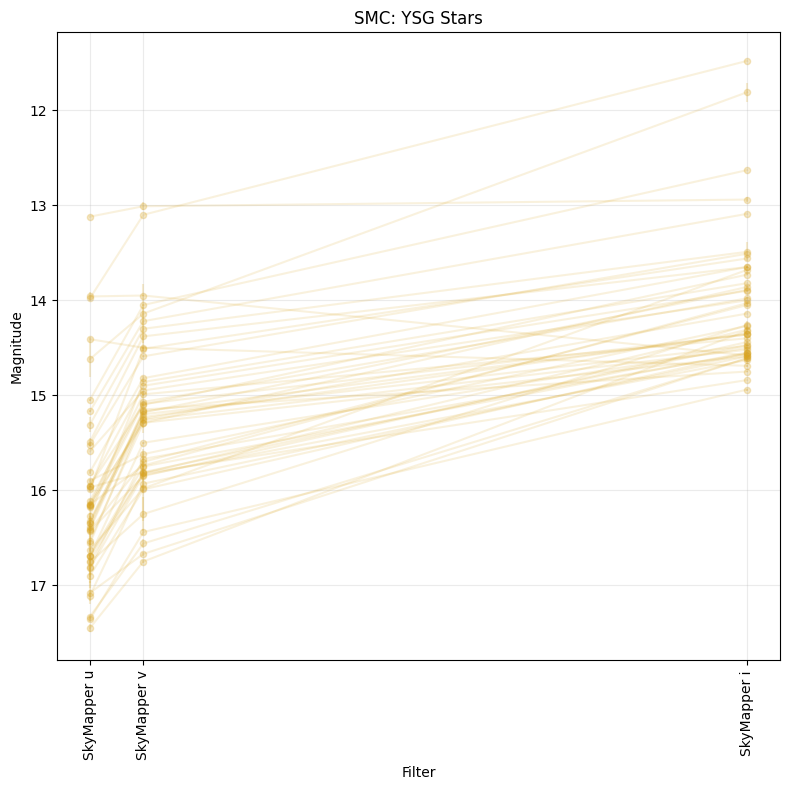

PosixPath('/content/drive/MyDrive/★ Research/Unresolved Binaries/Outputs/SED/SMC_YSG_SED.png')

In [17]:
# YSG
plot_sed(
    table=ysg_three,
    star_type="YSG",
    color="goldenrod",
    filename="SMC_YSG_SED.png"
)


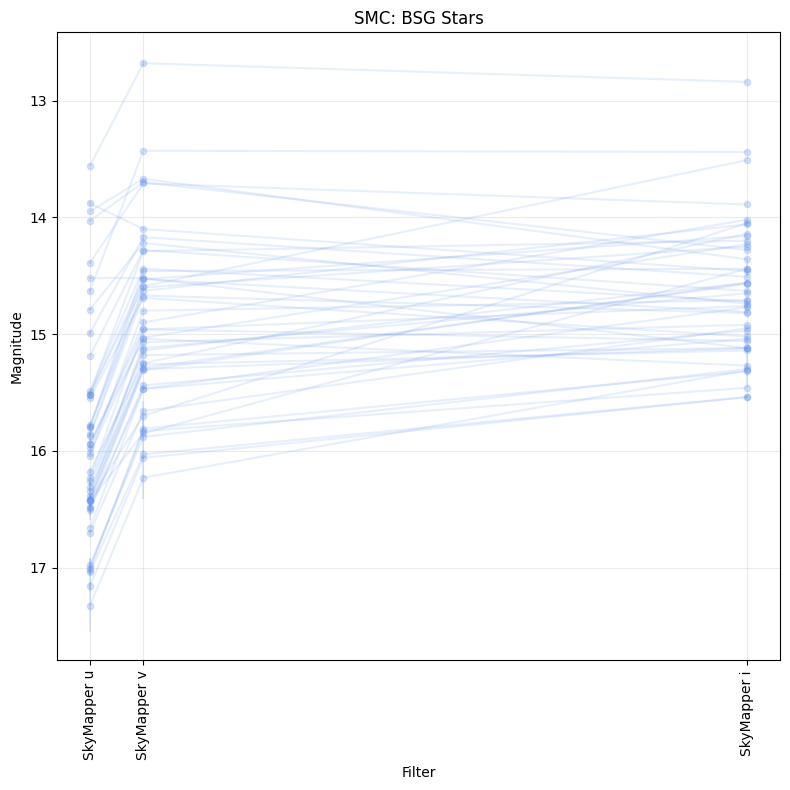

PosixPath('/content/drive/MyDrive/★ Research/Unresolved Binaries/Outputs/SED/SMC_BSG_SED.png')

In [18]:
# BSG

plot_sed(
    table=bsg_three,
    star_type="BSG",
    color="cornflowerblue",
    filename="SMC_BSG_SED.png"
)

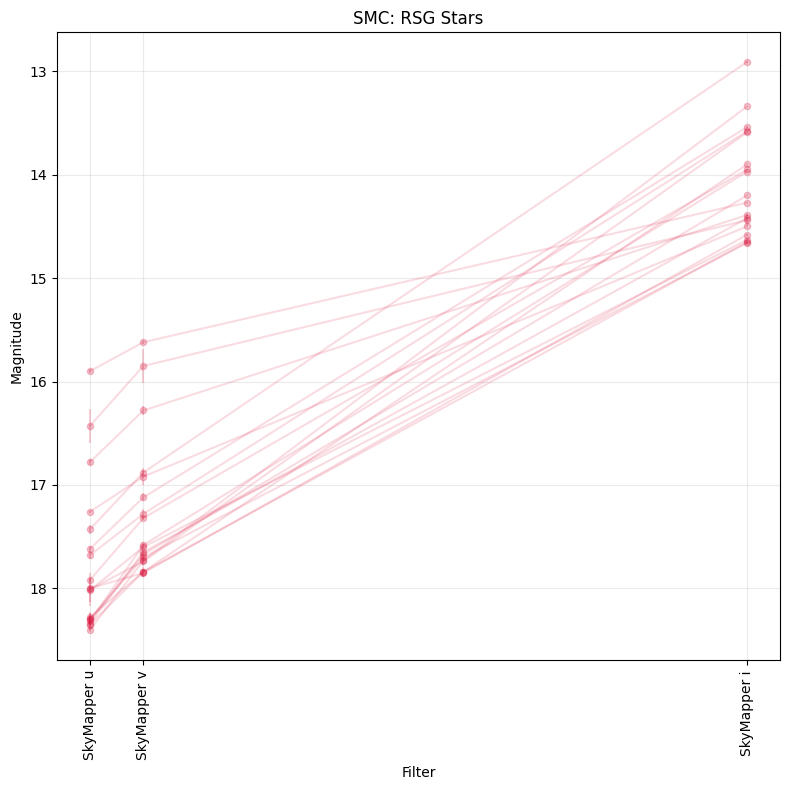

PosixPath('/content/drive/MyDrive/★ Research/Unresolved Binaries/Outputs/SED/SMC_RSG_SED.png')

In [19]:
# RSG

plot_sed(
    table=rsg_three,
    star_type="RSG",
    color="crimson",
    filename="SMC_RSG_SED.png"
)

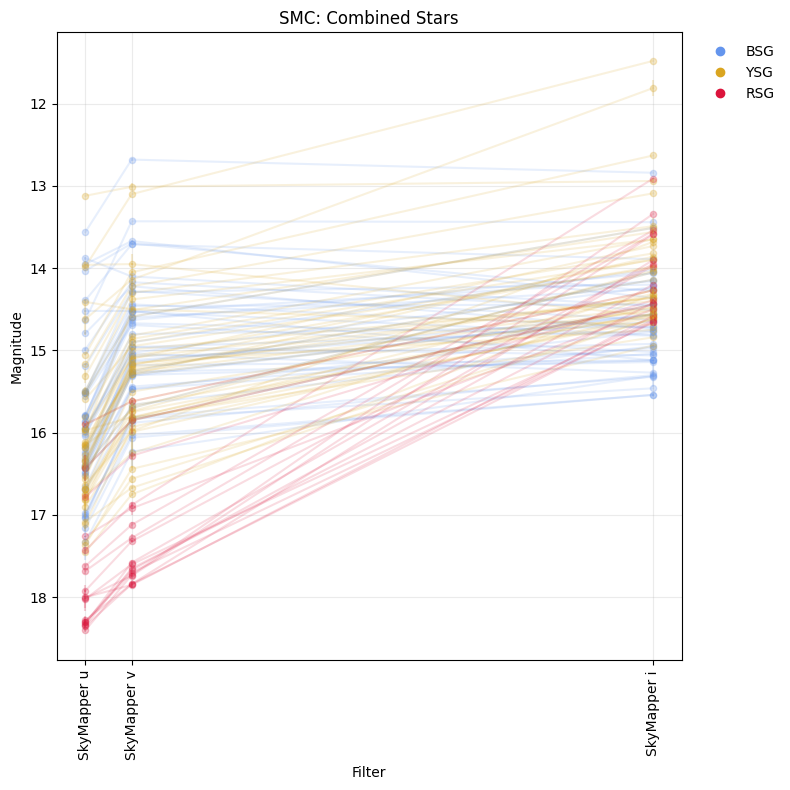

PosixPath('/content/drive/MyDrive/★ Research/Unresolved Binaries/Outputs/SED/SMC_Combined_SED.png')

In [21]:
plot_combined_sed(
    bsg_table=bsg_three,
    ysg_table=ysg_three,
    rsg_table=rsg_three,
    filename="SMC_Combined_SED.png"
)